In [1]:
!pip install albumentations -q

In [2]:
!pip install timm -U -q
!pip install urllib3==1.25.4 -q
!pip install boto3 -U -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
docker 6.1.3 requires urllib3>=1.26.0, but you have urllib3 1.25.4 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
awscli 1.27.157 requires botocore==1.29.157, but you have botocore 1.31.8 which is incompatible.
sagemaker 2.167.0 requires PyYAML==6.0, but you have pyyaml 5.4.1 which is incompatible.


In [3]:
import albumentations as A
import albumentations.augmentations.functional as F

import copy
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
import timm
import torch
import torchvision as tv
import torch.nn as nn
import json
import boto3
from io import BytesIO
from io import StringIO
from urllib.parse import urlparse
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import GroupKFold, KFold
import gc
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix,
    f1_score, 
    precision_score, 
    recall_score,
    roc_auc_score,
    balanced_accuracy_score,
    average_precision_score
)
from torch.cuda.amp import GradScaler
from torch.cuda.amp import autocast
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import time
import seaborn as sns


In [4]:
client = boto3.client("s3")

def list_all_objects_in_s3(bucketName, prefixName=None):
    """Get a list of objects in an S3 bucket path.
    @params:
    bucketName : s3 bucket 
    prefixName : s3 prefix to bucket
    returns : list of objects in s3 path
    [example of S3 bucket with prefix f"s3://{bucketName}/{prefix}"]
    """
    if prefixName:
        resp = client.list_objects_v2(Bucket=bucketName, StartAfter=prefixName)
    else:
        resp = client.list_objects_v2(Bucket=bucketName)
    list_of_files=[]
    for obj in resp['Contents']:
        files = bucketName+'/'+obj['Key']
        if prefixName:
            if prefixName in files:
                if prefixName!=files:
                    list_of_files.append(files)
        else:
            list_of_files.append(files)
    return list_of_files

def from_s3_npy(s3_uri: str):
    """
    @params 
    data : file content 
    s3_uri : s3 file path along with name [example of S3 bucket with prefix f"s3://{bucketName}/{prefix}/{fileName.npy}"]
    """
    try:
        bytes_ = BytesIO()
        parsed_s3 = urlparse(s3_uri)
        client.download_fileobj(
            Fileobj=bytes_, Bucket=parsed_s3.netloc, Key=parsed_s3.path[1:]
        )
        bytes_.seek(0)
        np_data=np.load(bytes_, allow_pickle=True)
    
    except Exception as e: # work on python 3.x
        print('Failed to read numpy array from S3: '+ str(e))
    return np_data

s3 = boto3.resource("s3")
def read_file_from_s3(bucket, file):
    try:
        obj = s3.Object(bucket, file)
        data = obj.get()["Body"]
        
    except Exception as e: # work on python 3.x
        print("Failed to read file from S3: "+ str(e))
    return data.read().decode(encoding="utf-8")

In [595]:
train = pd.read_csv(StringIO(read_file_from_s3("master-annotation-files", "train_annotations.csv")))
valid = pd.read_csv(StringIO(read_file_from_s3("master-annotation-files", "val_annotations.csv")))
test = pd.read_csv(StringIO(read_file_from_s3("master-annotation-files", "test_annotations.csv")))


In [596]:
train = train[train["sl"] <= 160]
valid = valid[valid["sl"] <= 160]
test = test[test["sl"] <= 160]

In [597]:
train["image"] = train[["scan_id", "sl"]].astype(str).agg("_".join, axis=1)
valid["image"] = valid[["scan_id", "sl"]].astype(str).agg("_".join, axis=1)
test["image"] = test[["scan_id", "sl"]].astype(str).agg("_".join, axis=1)


In [598]:
test.drop(test[test["scan_id"] == "MTR_178"].index, inplace=True)
test = test.reset_index()
test = test.drop("index", axis=1)

In [612]:
train_cv = pd.concat([train, valid])

In [613]:
train_cv = train_cv.loc[:, ["image", "scan_id", "sl"]]

In [614]:
train_cv.shape

(11013, 3)

In [615]:
test_set = test.loc[:, ["image", "scan_id", "sl"]]

In [616]:
test_set.shape

(5132, 3)

In [617]:
train_cv = train_cv.assign(abnormality=1.0)
test_set = test_set.assign(abnormality=1.0)

In [618]:
train_cv = train_cv.drop_duplicates()
test_set = test_set.drop_duplicates()

In [619]:
train_cv.shape

(6160, 4)

In [620]:
test_set.shape

(2991, 4)

In [621]:
new_df_train = pd.DataFrame()
for scan_id in train_cv["scan_id"].unique():
    df = pd.DataFrame(
        {
            "scan_id":scan_id,
            "sl": range(1, 161)
        }
    )
    new_df_train = pd.concat([new_df_train, df])

In [622]:
new_df_test = pd.DataFrame()
for scan_id in test_set["scan_id"].unique():
    df = pd.DataFrame(
        {
            "scan_id":scan_id,
            "sl": range(1, 161)
        }
    )
    new_df_test = pd.concat([new_df_test, df])

In [623]:
new_df_train["image"] = new_df_train[["scan_id", "sl"]].astype(str).agg("_".join, axis=1)
new_df_test["image"] = new_df_test[["scan_id", "sl"]].astype(str).agg("_".join, axis=1)

In [629]:
new_train = pd.DataFrame()
new_test = pd.DataFrame()

new_train = new_df_train.merge(train_cv, on=["image", "scan_id", "sl"], how="left")
new_test = new_df_test.merge(test_set, on=["image", "scan_id", "sl"], how="left")

In [630]:
new_train = new_train.fillna(0.0)
new_test = new_test.fillna(0.0)

In [631]:
new_train["normal"] = np.where((new_train["abnormality"]==1), 0.0, 1.0)
new_test["normal"] = np.where((new_test["abnormality"]==1), 0.0, 1.0)


In [632]:
new_train

,scan_id,sl,image,abnormality,normal
0,MTR_104,1,MTR_104_1,0.0,1.0
1,MTR_104,2,MTR_104_2,0.0,1.0
2,MTR_104,3,MTR_104_3,0.0,1.0
3,MTR_104,4,MTR_104_4,0.0,1.0
4,MTR_104,5,MTR_104_5,0.0,1.0
...,...,...,...,...,...
15195,MTR_045,156,MTR_045_156,0.0,1.0
15196,MTR_045,157,MTR_045_157,0.0,1.0
15197,MTR_045,158,MTR_045_158,0.0,1.0
15198,MTR_045,159,MTR_045_159,0.0,1.0


In [633]:
new_train = new_train.drop(["scan_id", "sl"], axis=1)
new_test = new_test.drop(["scan_id", "sl"], axis=1)

In [634]:
new_train.sum(axis=0)

image          MTR_104_1MTR_104_2MTR_104_3MTR_104_4MTR_104_5M...
abnormality                                               6160.0
normal                                                    9040.0
dtype: object

In [635]:
new_test.sum(axis=0)

image          MTR_173_1MTR_173_2MTR_173_3MTR_173_4MTR_173_5M...
abnormality                                               2991.0
normal                                                    2449.0
dtype: object

In [ ]:
timm.list_models()

In [636]:
# Global variables
N_FOLDS = 3
MAX_LR = 2.0e-4
SAVE_CHECKPOINT_EVERY_STEP = 2000
CHECKPOINT_PATH = "/home/ec2-user/SageMaker/models"
PREDICT_MAX_BATCHES = 1e9
MAX_TRAIN_BATCHES = 10000
EPOCHS = 10
BACKBONE = "efficientnet_b1"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    BATCH_SIZE = 8
else:
    BATCH_SIZE = 2

In [637]:
# CV splits
split = GroupKFold(N_FOLDS)

for k, (_, test_idx) in enumerate(split.split(new_train, groups=new_train.image)):
    new_train.loc[test_idx, "split"] = k

In [638]:
new_train.sample(5)

,image,abnormality,normal,split
6759,MTR_200_40,0.0,1.0,1.0
8942,MTR_161_143,1.0,0.0,2.0
2972,MTR_008_93,0.0,1.0,1.0
7033,MTR_201_154,0.0,1.0,2.0
4502,MTR_129_23,0.0,1.0,0.0


In [639]:
class LesionDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=None):
        super().__init__()
        self.df = df
        self.transform = transform
        self.classes = ["abnormality", "normal"]
        
    def __getitem__(self, i):
        row = self.df.iloc[i]
        image_id = row.image
        #print(image_id)
        img = from_s3_npy("s3://skm-dataset-echo1/" + image_id + ".npy")

        # Apply image transformations (if any)
        if self.transform is not None:
            x = self.transform(image=img)["image"]
        else:
            x = img

        # Labels
        y = torch.tensor(np.array([float(row[c]) for c in self.classes]), dtype=torch.float32)

        return x, y

    def __len__(self):
        return len(self.df)

In [640]:
# Image augmentations
train_transform = A.Compose([
    A.GaussianBlur((3, 7), p=0.25),
    A.RandomRotate90(p=0.25),
    A.OneOf([
        A.MotionBlur(p=0.2),
        A.Blur(blur_limit=3, p=0.1),
    ], p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.2, rotate_limit=45, interpolation=cv2.INTER_LINEAR, border_mode=cv2.BORDER_CONSTANT, p=0.25),
    A.OneOf([
        A.OpticalDistortion(p=0.3),
        A.GridDistortion(p=0.1),
    ], p=0.25),
    ToTensorV2(p=1.0)
])

valid_transform = A.Compose([
    ToTensorV2(p=1.0)
])
     

In [641]:
# Check the dataset outputs
dataset_train = LesionDataset(new_train, train_transform)
x, y = dataset_train[100]
print(x.shape, y.shape)

torch.Size([1, 512, 512]) torch.Size([2])


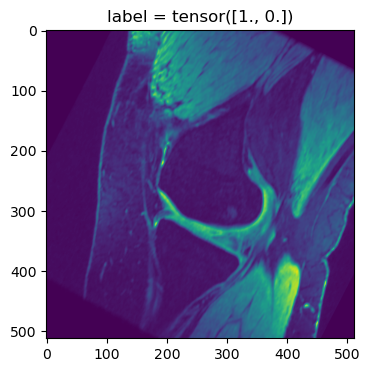

In [642]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))
ax.imshow(np.transpose(x, (1, 2, 0)))
ax.set_title(f"label = {y}")
plt.show()

In [643]:
# Custom model class
class LesionModel(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.model = timm.create_model(backbone, pretrained=True, in_chans=1, num_classes=2)

    def forward(self, x):
        x = self.model(x)
        return x

In [644]:
# Quick test of the model
print(BACKBONE)
model = LesionModel(BACKBONE)
print(model(torch.randn(1, 1, 512, 512)))
del model

efficientnet_b1
tensor([[0.6126, 1.5684]], grad_fn=<AddmmBackward0>)


In [645]:
def gc_collect():
    """Performs garbage removal after memory-intensive operations."""
    gc.collect()
    torch.cuda.empty_cache()
    
def load_model(model, path, device="cpu"):
    """Loads a model from a specified location.

    Args:
        model: An instance of the model class to load.
        path: A path to load model weights from.
        device: A device to place the model onto.

    Returns:
        model: The model with the loaded weights.
    """
    weights = torch.load(os.path.join(path), map_location=device)
    model.load_state_dict(weights)
    return model

def save_model(model, path):
    """Saves a model.

    Args:
        model: The model to save.
        path: The path to the saved model file.
    """
    torch.save(model.state_dict(), path)
    
def save_cm(df, path):
    df.to_csv(path, index=False)

In [646]:
def get_top_k_metrics(y_true, y_pred, k):
    """Retrieves the top-n predictions.

    Args:
        y_true: An array of the true sample labels.
        y_pred: An array of the predicted sample probabilities.
        k: The number of top class probabilities to consider.
    Returns:
        metrics: A dict of top-k metrics (accuracy, precision, recall, f1, confusion matrix)
    """
    y_true_labels = np.argmax(y_true, axis=1)
    sorted_pred = np.argsort(y_pred, axis=1, kind="mergesort")[:, ::-1][:, :k]
    hits = (y_true_labels == sorted_pred.T).any(axis=0).astype(np.uint8)
    #accuracy = hits.mean()
    balanced_accuracy = balanced_accuracy_score(y_true_labels, sorted_pred)
    tp = np.array([hits[y_true_labels == i].sum() for i in range(2)])
    fn = np.array([((y_true_labels == i) & np.logical_not((sorted_pred == i).any(axis=1))).sum() for i in range(2)])
    fp = np.array([((y_true_labels != i) & (hits == 0) & (sorted_pred == i).any(axis=1)).sum() for i in range(2)])
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f2 = (1 + 2.0 ** 2) * precision * recall / (2.0 ** 2 * precision + recall)
    cm = np.array([[((y_true_labels == i) & (sorted_pred == j).any(axis=1)).sum() for j in range(2)] for i in range(2)])
    metrics = {
        "balanced_accuracy": balanced_accuracy,
        "precision": precision,
        "recall": recall,
        "f2": f2,
        "confusion_matrix": cm
    }
    return metrics

In [223]:
def evaluate_classification_model(
    model, 
    dataset, 
    max_batches, 
    device="cpu", 
    batch_size=2,
    shuffle=False
):
    """Evaluates a lesion classification model against a dataset.

    Args:
        model: A model to be evaluated.
        dataset: A dataset object containing images to evaluate the model with.
        max_batches: The number of batches to run the evaluation loop for. If the number of
            iterations exceeds max_batches, the loop will terminate.
        device: A device to run the evaluation loop on.
        batch_size: The number of images to process at the same time.
        shuffle: A boolean signifying whether or not to shuffle the dataset.

    Returns:
        loss: The average cross-entropy loss across all images in the dataset.
        roc_auc: The average ROC AUC score across all classes and images in the dataset.
        f1: The average F1 score across all classes and images in the dataset.
    """
    torch.manual_seed(42)
    model = model.to(device)
    model.eval()
    loader_test = torch.utils.data.DataLoader(
        dataset, 
        batch_size=batch_size, 
        shuffle=shuffle, 
        num_workers=os.cpu_count()
    )
    y_true = []
    y_pred = []
    total_loss = 0.0
    n = 0
    with torch.no_grad():
        with tqdm(loader_test) as loader_:
            for i, (x, y) in enumerate(loader_):
                x = x.to(device, dtype=torch.float)
                y = y.to(device)
                logits = model(x)
                #loss = nn.CrossEntropyLoss()(logits, y.float())
                loss = nn.BCEWithLogitsLoss()(logits, y.float())
                y_pred.append(torch.nn.functional.softmax(logits, dim=-1).cpu().numpy())
                y_true.append(y.cpu().numpy())
                total_loss += loss.item() * x.size(0)
                n += x.size(0)
                loader_.set_description(f"loss = {total_loss / n:.04f}")
                if i >= max_batches:
                    break
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    loss = total_loss / n
    roc_auc = roc_auc_score(y_true, y_pred, multi_class="ovr", average="macro")
    print("\n\n[EVALUATION METRICS]")
    print(f"Loss: {loss:.04f}")
    print(f"ROC AUC: {roc_auc:.04f}\n")
    for k in range(1, 2):
        metrics = get_top_k_metrics(y_true, y_pred, k)
        print(f"F2: {metrics['f2'].mean():.04f}")
        print(f"Precision: {metrics['precision'].mean():.04f}")
        print(f"Recall: {metrics['recall'].mean():.04f}")
        print(f"Balanced Accuracy: {metrics['balanced_accuracy'].mean():.04f}")
        if k == 1:
            cm = pd.DataFrame(metrics["confusion_matrix"], index=dataset.classes, columns=dataset.classes)
            print(f"Confusion Matrix:\n{cm}")
        print()
    return loss, cm

def train_classification_model(
    model,
    dataset_train,
    dataset_valid,
    path,
    path_cm,
    class_weights=None,
    batch_size=8,
    device="cpu",
    epochs=1,
    max_lr=2.0e-4
):
    """Trains a classification model.

    Args:
        model: The model to train.
        dataset_train: A training dataset.
        dataset_valid: A validation dataset.
        path: A path to save the model to.
        class_weights: The relative weight of each lesion class when computing the cross-entropy loss.
        batch_size: The number of images to process at the same time.
        device: A device to run the training loop on.

    Returns:
        model: The best model from the training loop.
    """
    torch.manual_seed(42)
    loader_train = torch.utils.data.DataLoader(
        dataset_train, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=os.cpu_count(),
        pin_memory=True,
        timeout=120
    )
    optim = torch.optim.RAdam(model.parameters())
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optim, 
        max_lr=max_lr, 
        epochs=epochs,
        steps_per_epoch=len(loader_train),
        pct_start=0.3
    )
    model.train()
    if class_weights is not None:
        class_weights = torch.tensor(class_weights).to(device)
    scaler = GradScaler()
    best_loss = float("inf")
    best_cm = pd.DataFrame()
    best_model = copy.deepcopy(model)
    for epoch in range(epochs):
        print(f"[EPOCH {epoch + 1}/{epochs}]")
        with tqdm(loader_train) as loader_:
            total_loss = 0.0
            n = 0
            for i, (x, y) in enumerate(loader_):
                optim.zero_grad()
                with autocast():
                    x = x.to(device, dtype=torch.float)
                    y = y.to(device)
                    logits = model(x)
                    loss = nn.BCEWithLogitsLoss(weight=class_weights)(logits, y.float())
                    if np.isinf(loss.item()) or np.isnan(loss.item()):
                        print(f"Bad loss, skipping batch {i}")
                        del loss
                        gc_collect()
                        continue
                scaler.scale(loss).backward()
                scaler.step(optim)
                scaler.update()
                scheduler.step()
                total_loss += loss.item() * x.size(0)
                n += x.size(0)
                loader_.set_description(f"loss = {total_loss / n :.04f}")
        loss, cm = evaluate_classification_model(
            model, 
            dataset_valid, 
            max_batches=10000, 
            device=device, 
            batch_size=batch_size,
            shuffle=False
        )
        if loss < best_loss: 
            save_model(model, path)
            best_loss = loss
            best_model = copy.deepcopy(model)
            save_cm(cm, path_cm)
    return best_model

def predict_lesion(x, y, model, device, verbose=True):
    """Predicts the lesion class for a given image.

    Args:
        x: An image to predict lesions for.
        y: The true label for the image.
        model: A model to use to make predictions.
        device: A device to evaluate on.
        verbose: A boolean flag indicating whether or not to display additional information.
    """
    x = x.to(device, dtype=torch.float)[None, :]
    y = y.to(device)[None, :]
    model = model.to(device)
    model.eval()
    with torch.no_grad():
        logits = model(x)
        loss = nn.BCEWithLogitsLoss()(logits, y.float())
        y_pred = torch.nn.functional.softmax(logits, dim=-1)[0]
        loss += loss.item()
    if verbose:
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))
        ax.imshow(np.transpose(x[0].cpu().numpy(), (1, 2, 0)))
        print(f"y_true = {y.cpu().numpy()[0]}")
        print(f"y_pred = {np.around(y_pred.cpu().numpy(), 3)}")


def visualize_features(x, y, model, device, k=1):
    """Visualizes the learned kernel features of a CNN model.

    Args:
        x: An image to predict lesions for.
        y: The true label for the image.
        model: A model to use to make predictions.
        device: A device to evaluate on.
    """
    x = x.to(device, dtype=torch.float)[None, :]
    y = y.to(device)[None, :]
    model = model.to(device)
    model.eval()
    with torch.no_grad():
        layers = list(model.model.children())
        f = x
        for i in range(k):
            layer = layers[i]
            f = layer(f)
    fig, axs = plt.subplots(nrows=8, ncols=4, figsize=(4 * 4, 8 * 4))
    for i in range(8):
        for j in range(4):
            ax = axs[i, j]
            ax.imshow(f[0, i + j].cpu().numpy())
            ax.set_title(i + j)

In [650]:
# Training loop
t0 = time.time()
classification_models = []
for fold in range(N_FOLDS):
    print(f"[FOLD {fold + 1}/{N_FOLDS}]")
    path = os.path.join(CHECKPOINT_PATH, f"abnorm_efficientnetb1-f{fold}.tph")
    path_cm = os.path.join(CHECKPOINT_PATH, f"abnorm_cm_efficientnetb1-f{fold}.csv")
    # Load the models if they already exist
    if os.path.exists(path):
        print(f"Found cached version of {path}")
        classification_models.append(load_model(LesionModel(BACKBONE), path, DEVICE))
    else:
        gc_collect()
        dataset_train = LesionDataset(new_train.query("split != @fold"), train_transform)
        dataset_valid = LesionDataset(new_train.query("split == @fold"), valid_transform)
        model = LesionModel(BACKBONE).to(DEVICE)
        classification_models.append(
            train_classification_model(
                model,
                dataset_train,
                dataset_valid,
                path,
                path_cm,
                class_weights=None,
                batch_size=BATCH_SIZE,
                device=DEVICE,
                epochs=EPOCHS,
                max_lr=MAX_LR
            )
        )
        
print(f"total training time: {time.time() - t0}")

[FOLD 1/3]
[EPOCH 1/10]


  0%|          | 0/1267 [00:00<?, ?it/s]/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:139: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "
loss = 0.4564: 100%|██████████| 634/634 [00:55<00:00, 11.50it/s]




[EVALUATION METRICS]
Loss: 0.4564
ROC AUC: 0.9111

F2: 0.8140
Precision: 0.8220
Recall: 0.8128
Balanced Accuracy: 0.8128
Confusion Matrix:
             abnormality  normal
abnormality         1545     525
normal               362    2635

[EPOCH 2/10]


loss = 0.2895: 100%|██████████| 634/634 [00:53<00:00, 11.89it/s]




[EVALUATION METRICS]
Loss: 0.2895
ROC AUC: 0.9524

F2: 0.8705
Precision: 0.8641
Recall: 0.8737
Balanced Accuracy: 0.8737
Confusion Matrix:
             abnormality  normal
abnormality         1858     212
normal               450    2547

[EPOCH 3/10]


...



[EVALUATION METRICS]
Loss: 0.1235
ROC AUC: 0.9942

F2: 0.9652
Precision: 0.9636
Recall: 0.9656
Balanced Accuracy: 0.9656
Confusion Matrix:
             abnormality  normal
abnormality         1967      73
normal               100    2926

[EPOCH 9/10]


loss = 0.1515: 100%|██████████| 634/634 [00:53<00:00, 11.81it/s]




[EVALUATION METRICS]
Loss: 0.1515
ROC AUC: 0.9933

F2: 0.9633
Precision: 0.9642
Recall: 0.9631
Balanced Accuracy: 0.9631
Confusion Matrix:
             abnormality  normal
abnormality         1944      96
normal                81    2945

[EPOCH 10/10]


loss = 0.1486: 100%|██████████| 634/634 [00:53<00:00, 11.94it/s]



[EVALUATION METRICS]
Loss: 0.1486
ROC AUC: 0.9934

F2: 0.9630
Precision: 0.9642
Recall: 0.9627
Balanced Accuracy: 0.9627
Confusion Matrix:
             abnormality  normal
abnormality         1941      99
normal                79    2947

total training time: 7037.581357717514


In [657]:
cm = pd.read_csv("models/abnorm_cm_efficientnetb1-f0.csv")
cm = cm.rename(index = {0:"Abnormality", 1:"Normal"})
cm

,abnormality,normal
Abnormality,1998,72
Normal,77,2920


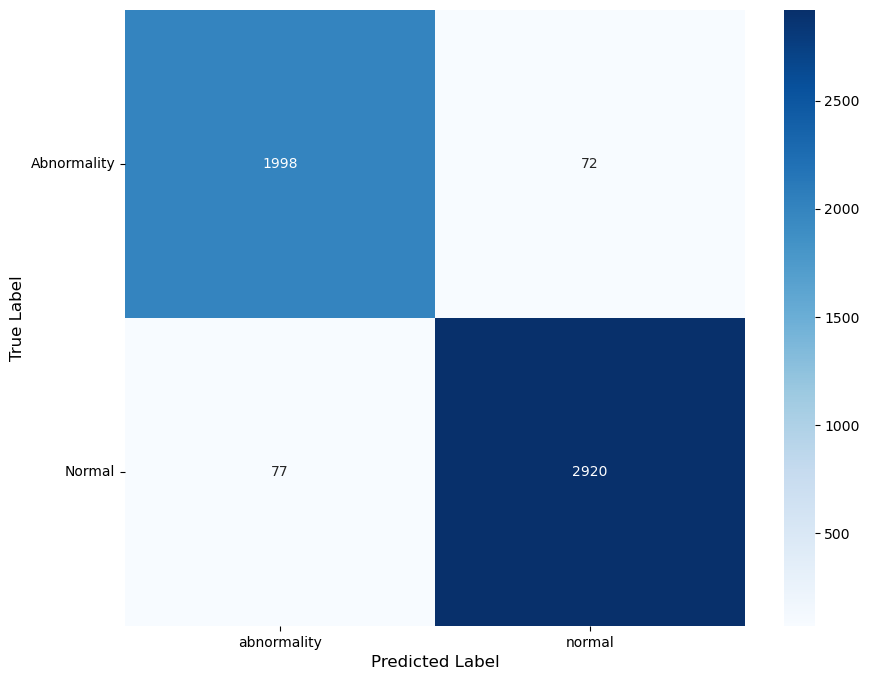

In [658]:
plt.figure(figsize = (10, 8))
p = sns.heatmap(cm, cmap="Blues", annot=True, fmt="g")
p.set_yticklabels(labels = ["Abnormality", "Normal"], rotation=0)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.show()

In [345]:
new_test

,image,Cartilage Lesion,Ligament Tear,Meniscal Tear,Other Lesion,No Lesion
0,MTR_005_1,0.0,0.0,0.0,0.0,1.0
1,MTR_005_2,0.0,0.0,0.0,0.0,1.0
2,MTR_005_3,0.0,0.0,0.0,0.0,1.0
3,MTR_005_4,0.0,0.0,0.0,0.0,1.0
4,MTR_005_5,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...
5595,MTR_248_156,0.0,0.0,0.0,0.0,1.0
5596,MTR_248_157,0.0,0.0,0.0,0.0,1.0
5597,MTR_248_158,0.0,0.0,0.0,0.0,1.0
5598,MTR_248_159,0.0,0.0,0.0,0.0,1.0


In [346]:
new_test.sum(axis=0)

image               MTR_005_1MTR_005_2MTR_005_3MTR_005_4MTR_005_5M...
Cartilage Lesion                                                759.0
Ligament Tear                                                   165.0
Meniscal Tear                                                   305.0
Other Lesion                                                   2728.0
No Lesion                                                      2490.0
dtype: object

In [653]:
dataset_test = LesionDataset(new_test, valid_transform)


In [659]:
model = load_model(LesionModel(BACKBONE), "models/abnorm_efficientnetb1-f0.tph").to(DEVICE)

In [667]:
i = np.argwhere(new_test["abnormality"].values == 1.0)[600][0]
x, y = dataset_test[i]

y_true = [1. 0.]
y_pred = [0.835 0.165]


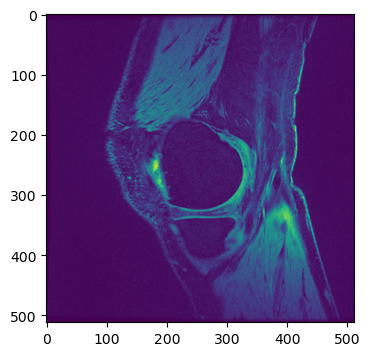

In [668]:
predict_lesion(x, y, model, DEVICE)


In [669]:
def predict_lesion_test(x, y, model, device):
    """Predicts the lesion class for a given image.

    Args:
        x: An image to predict lesions for.
        y: The true label for the image.
        model: A model to use to make predictions.
        device: A device to evaluate on.
    """

    x = x.to(device, dtype=torch.float)[None, :]
    y = y.to(device)[None, :]
    model = model.to(device)
    model.eval()
    with torch.no_grad():
        logits = model(x)
        y_pred = torch.nn.functional.softmax(logits, dim=-1).cpu().numpy()
        y_true = y.cpu().numpy()
        
    return y_true, y_pred

In [670]:
model = load_model(LesionModel(BACKBONE), "models/abnorm_efficientnetb1-f0.tph").to(DEVICE)
dataset_test = LesionDataset(new_test, valid_transform)

y_true_list = []
y_pred_list = []

for i in range(len(dataset_test)):
    x, y = dataset_test[i]
    y_true, y_pred = predict_lesion_test(x, y, model, DEVICE)
    y_pred_list.append(y_pred)
    y_true_list.append(y_true)

y_true_list = np.concatenate(y_true_list)
y_pred_list = np.concatenate(y_pred_list)



In [671]:
classes = ["Abnormality", "Normal"]


In [672]:
metrics = get_top_k_metrics(y_true_list, y_pred_list, 1)

print(f"F2: {metrics['f2'].mean():.04f}")
print(f"Precision: {metrics['precision'].mean():.04f}")
print(f"Recall: {metrics['recall'].mean():.04f}")
print(f"Balanced Accuracy: {metrics['balanced_accuracy'].mean():.04f}")
cm = pd.DataFrame(metrics["confusion_matrix"], index=classes, columns=classes)
save_cm(cm, "models/test_cm.csv")


F2: 0.8727
Precision: 0.8707
Recall: 0.8743
Balanced Accuracy: 0.8743


In [673]:
test_cm = pd.read_csv("models/test_cm.csv")
test_cm = test_cm.rename(index = {0:"Abnormality", 1:"Normal"})


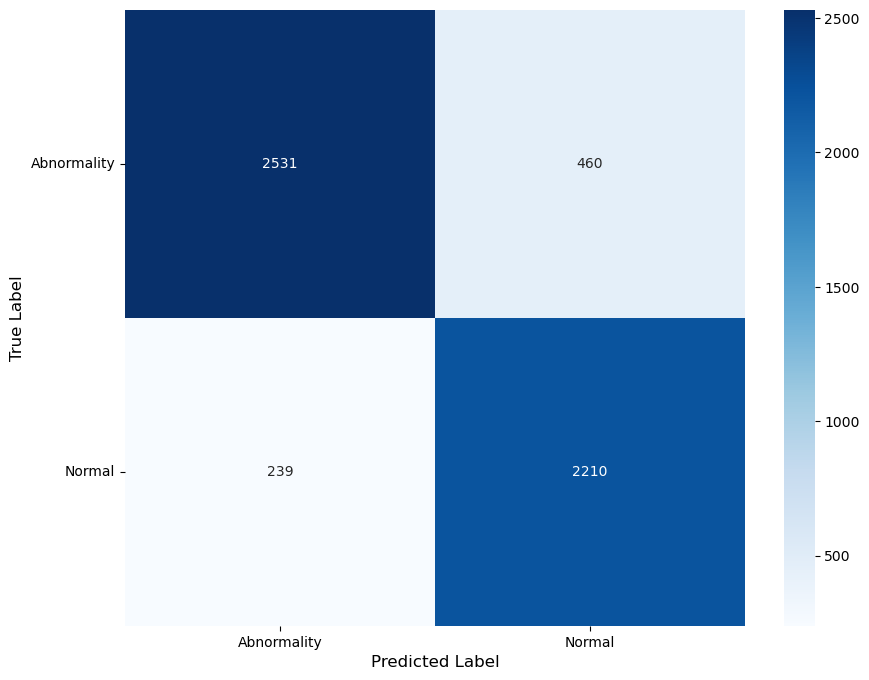

In [674]:
plt.figure(figsize = (10, 8))
p = sns.heatmap(test_cm, cmap="Blues", annot=True, fmt="g")
p.set_yticklabels(labels = ["Abnormality", "Normal"], rotation=0)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.show()